<a href="https://colab.research.google.com/github/cryonixx/Data_Baes_DeepLearning_Codes/blob/main/Experiment_2_Redemption_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil

os.environ['KAGGLE_API_TOKEN'] = "KGAT_050ee8708b6181fc2b0c80c381279921"
print("Authenticating with Kaggle...")

dataset_zip = 'wesad-wearable-stress-affect-detection-dataset.zip'
dataset_dir = 'wesad_data/'

# Remove existing data if it exists to ensure a fresh download
if os.path.exists(dataset_dir):
    print(f"Removing existing directory: {dataset_dir}")
    shutil.rmtree(dataset_dir)
if os.path.exists(dataset_zip):
    print(f"Removing existing zip file: {dataset_zip}")
    os.remove(dataset_zip)

print("Downloading WESAD Dataset...")
!kaggle datasets download -d orvile/wesad-wearable-stress-affect-detection-dataset --force

print("Unzipping WESAD Dataset...")
!unzip -q -o {dataset_zip} -d {dataset_dir}

print("WESAD Dataset downloaded and unzipped successfully!")

Authenticating with Kaggle...
Dataset URL: https://www.kaggle.com/datasets/orvile/wesad-wearable-stress-affect-detection-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 2.43G/2.43G [01:02<00:00, 41.8MB/s]

Unzipping WESAD Dataset...
WESAD Dataset downloaded and unzipped successfully!


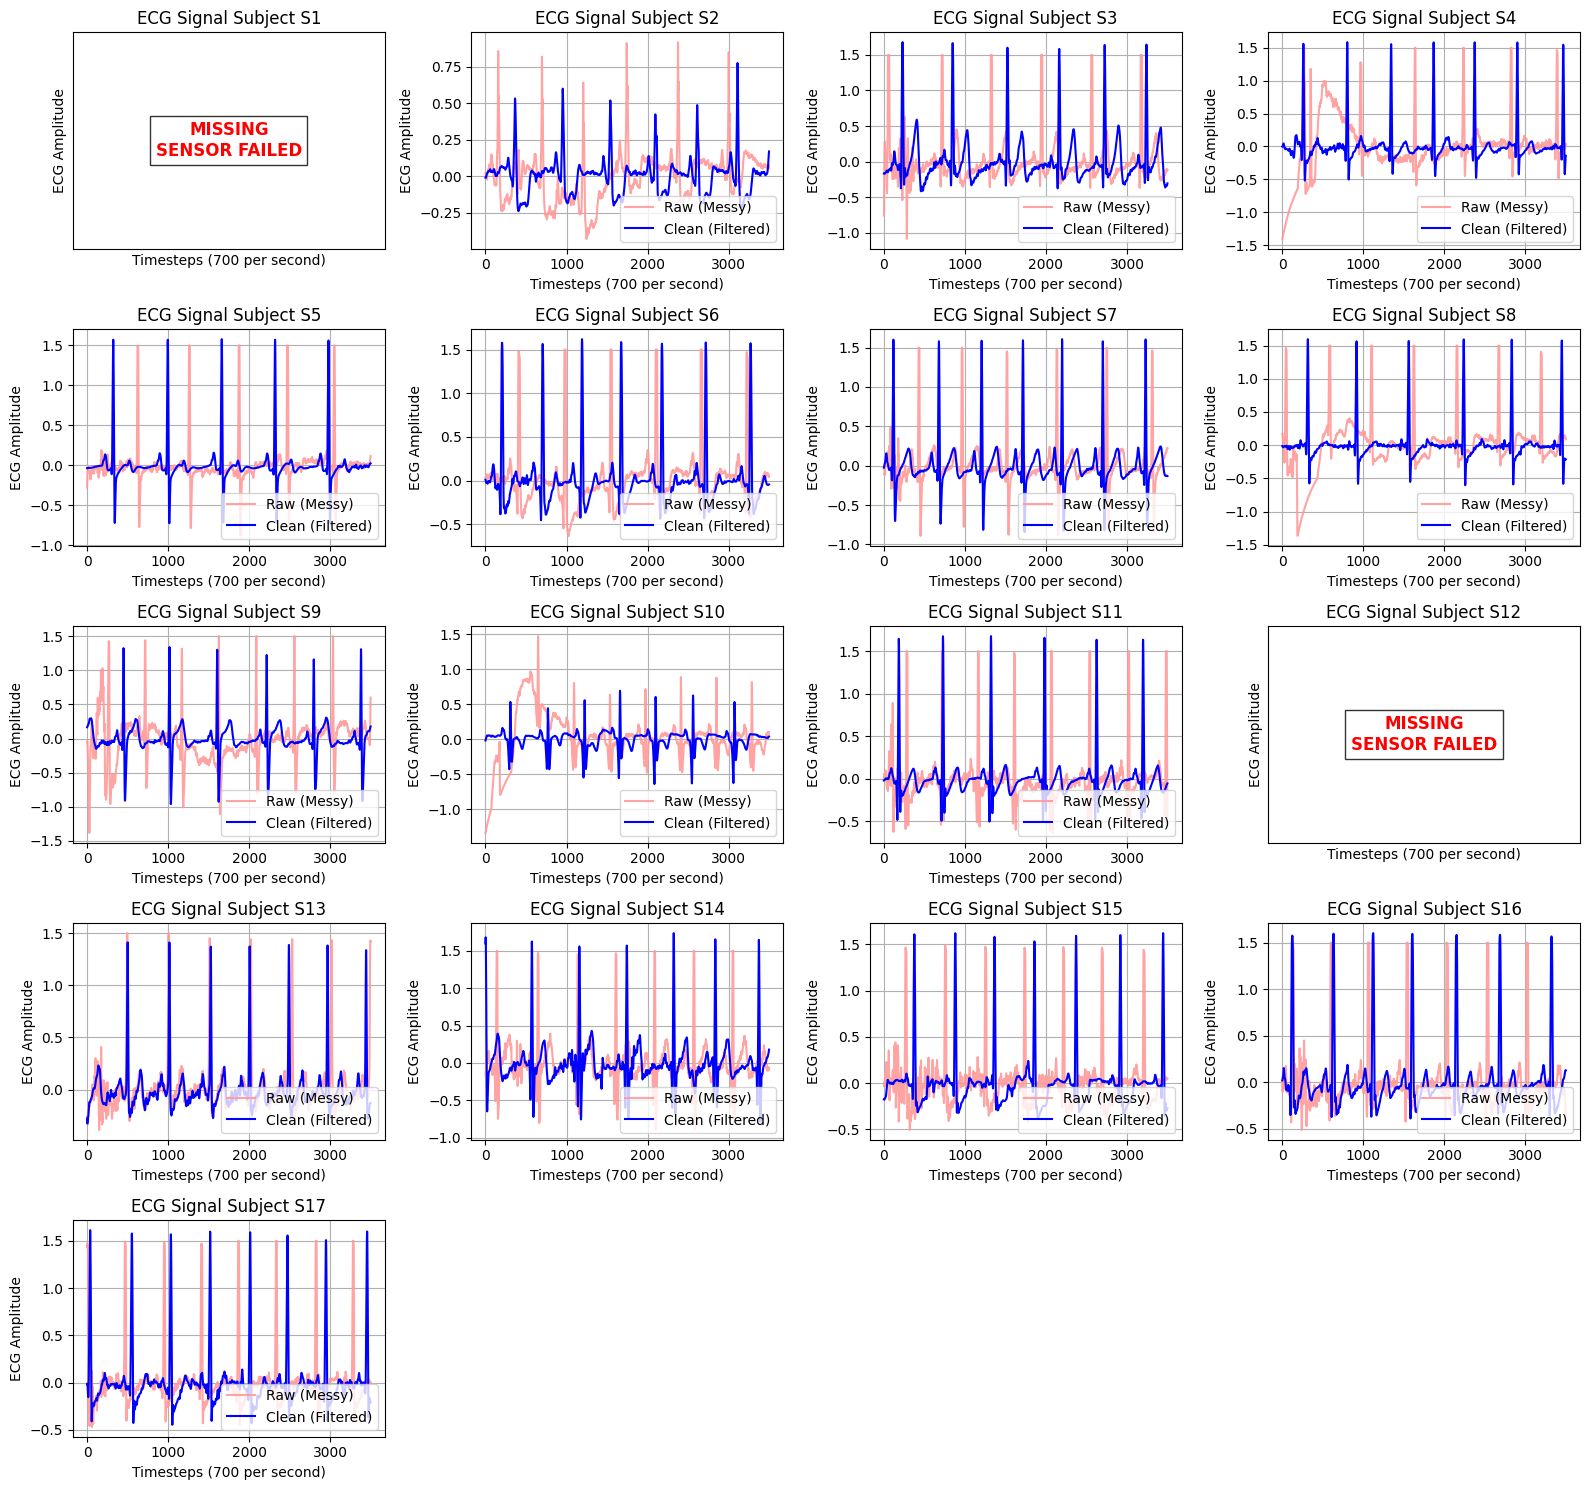

In [ ]:
import pickle
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from scipy import signal

def load_data(file_path):
    with open(file_path, 'rb') as f:
        # WESAD uses 'latin1' encoding for its pickles
        data = pickle.load(f, encoding='latin1')

    # Extract ECG from the chest sensor
    raw_ecg_signal = data['signal']['chest']['ECG'].flatten()
    raw_labels = data['label']

    return raw_ecg_signal, raw_labels

def butterworth_filter(raw_signal, low_cut=0.5, high_cut=40.0, fs=700, order=4):
    b, a = signal.butter(N= order, Wn= [low_cut, high_cut], btype ='bandpass', fs= fs)
    clean_signal = signal.filtfilt (b, a, raw_signal)

    return clean_signal

def filter_data_neutral_only(raw_ecg_signal, raw_labels):
    raw_ecg_signal = butterworth_filter(raw_ecg_signal)
    # Filter only for Neutral (1) and Stress (2)
    valid_indices = np.where((raw_labels == 1) | (raw_labels == 2))[0]

    filtered_ecg = raw_ecg_signal[valid_indices]
    filtered_labels = raw_labels[valid_indices]

    # Convert label '2' (Stress) to 1, and '1' (Neutral) to 0 for Binary Classification
    filtered_labels = np.where(filtered_labels == 2, 1, 0)

    return filtered_ecg, filtered_labels

def filter_data_neutral_amusement_meditation(raw_ecg_signal, raw_labels):
    raw_ecg_signal = butterworth_filter(raw_ecg_signal)
    # Filter all labels; Neutral (1), Stress (2), Amusement (3), Meditation (4)
    valid_indices = np.where((raw_labels >= 1) & (raw_labels <= 4))[0]

    filtered_ecg = raw_ecg_signal[valid_indices]
    filtered_labels = raw_labels[valid_indices]

    # Convert label '2' (Stress) to 1, and all other labels to 0 for Binary Classification
    filtered_labels = np.where(filtered_labels == 2, 1, 0)

    return filtered_ecg, filtered_labels


subjects = []
total_subjects = 17
exclude_subjects = {1, 12} # Subjects 1 and 12

columns = 4
rows = (total_subjects + columns - 1) // columns
fig, axs = plt.subplots(rows, columns, figsize=(columns * 4, rows * 3))
axs = np.atleast_2d(axs)
seconds_to_plot = 5
timesteps = seconds_to_plot * 700

for i in range(1, total_subjects + 1):
  idx = i - 1
  r = idx // columns
  c = idx % columns
  ax = axs[r, c]

  ax.set_title(f"ECG Signal Subject S{i}")
  ax.set_xlabel("Timesteps (700 per second)")
  ax.set_ylabel("ECG Amplitude")
  ax.grid(True)

  file_path = f"wesad_data/WESAD/S{i}/S{i}.pkl"

  if i in exclude_subjects or not os.path.exists(file_path):
    ax.text(0.5, 0.5, "MISSING\nSENSOR FAILED", color='red',
        fontsize=12, fontweight='bold', ha='center', va='center',
        transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.8))
    ax.set_xticks([]); ax.set_yticks([])
    continue

  # loading and preprocessing data
  raw_ecg, raw_labels = load_data(file_path)
  filtered_ecg, filtered_labels = filter_data_neutral_only(raw_ecg, raw_labels)
  subjects.append((filtered_ecg, filtered_labels))

  ax.plot(raw_ecg[:timesteps], color='#ff9999', alpha=0.9, label='Raw (Messy)')
  ax.plot(filtered_ecg[:timesteps], color='blue', linewidth=1.5, label='Clean (Filtered)')

  ax.legend(loc="lower right")

n_plots = rows * columns
for j in range(total_subjects, n_plots):
    r = j // columns
    c = j % columns
    axs[r, c].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def process_data(ecg, labels, window_size=7000, step_size=3500):
    # normalize across the whole signal
    scaler = StandardScaler()
    normalized_ecg = scaler.fit_transform(ecg.reshape(-1, 1)).flatten()

    print("ECG Signals normalized successfully.")

    # rolling window
    X, y = [], []
    for start in range(0, len(normalized_ecg) - window_size + 1, step_size):
        window = normalized_ecg[start:start + window_size]
        label = labels[start:start + window_size]
        majority_label = np.bincount(label.astype(int)).argmax()
        X.append(window.reshape(-1, 1))
        y.append(majority_label)

    return np.array(X), np.array(y)

# Create specific buckets for training and testing
train_X, train_y = [], []
test_X, test_y = [], []

test_subjects = {15, 16, 17} # Reserve these for the final exam

# Note: Your previous loop appended to 'subjects' in order.
# We need to re-extract with the subject ID to split them correctly.
for i in range(1, total_subjects + 1):
    if i in exclude_subjects:
        continue

    file_path = f"wesad_data/WESAD/S{i}/S{i}.pkl"
    if not os.path.exists(file_path):
        continue

    raw_ecg, raw_labels = load_data(file_path)
    filtered_ecg, filtered_labels = filter_data_neutral_only(raw_ecg, raw_labels)
    X_subj, y_subj = process_data(filtered_ecg, filtered_labels)

    # Sort into the correct bucket
    if i in test_subjects:
        test_X.append(X_subj)
        test_y.append(y_subj)
    else:
        train_X.append(X_subj)
        train_y.append(y_subj)

X_train = np.concatenate(train_X, axis=0)
y_train = np.concatenate(train_y, axis=0)
X_test = np.concatenate(test_X, axis=0)
y_test = np.concatenate(test_y, axis=0)

print(f"✅ Training on {len(X_train)} windows (Subjects 2-14)")
print(f"✅ Testing on {len(X_test)} windows (Subjects 15-17)")

ECG Signals normalized successfully.
ECG Signals normalized successfully.
ECG Signals normalized successfully.
ECG Signals normalized successfully.
ECG Signals normalized successfully.
ECG Signals normalized successfully.
ECG Signals normalized successfully.
ECG Signals normalized successfully.
ECG Signals normalized successfully.
ECG Signals normalized successfully.
ECG Signals normalized successfully.
ECG Signals normalized successfully.
ECG Signals normalized successfully.
ECG Signals normalized successfully.
ECG Signals normalized successfully.
✅ Training on 4376 windows (Subjects 2-14)
✅ Testing on 1119 windows (Subjects 15-17)


# MODEL TRAINING

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, MaxPooling1D
from tensorflow.keras.optimizers import Adam

print('Creating Deep LSTM Model...')

lstm_model = Sequential([
    MaxPooling1D(pool_size=5, input_shape=(7000, 1)),

    # Layer 1: Feature Extractor (Passes the full timeline forward)
    LSTM(units=64, return_sequences=True),

    # Layer 2: Decision Maker
    LSTM(units=32),

    # Softer safety net
    Dropout(rate=0.3),
    Dense(units=1, activation='sigmoid'),
])

# Manually slow down the learning rate for stability
optimizer_fine = Adam(learning_rate=0.0005)

lstm_model.compile(optimizer=optimizer_fine, loss='binary_crossentropy', metrics=['accuracy'])

print("Deep LSTM Model Created.")
lstm_model.summary()

Creating Deep LSTM Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/pooling/base_pooling.py:23: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(name=name, **kwargs)


✅ Deep LSTM Model Created


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ max_pooling1d (MaxPooling1D)    │ (None, 1400, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 1400, 64)       │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
import numpy as np

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))

history = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,       # bigger batch = more stable
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - accuracy: 0.5379 - loss: 0.6917 - val_accuracy: 0.6309 - val_loss: 0.6858 - learning_rate: 5.0000e-04
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.5912 - loss: 0.6751 - val_accuracy: 0.7936 - val_loss: 0.5747 - learning_rate: 5.0000e-04
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.6015 - loss: 0.6771 - val_accuracy: 0.6693 - val_loss: 0.6677 - learning_rate: 5.0000e-04
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.5786 - loss: 0.6856 - val_accuracy: 0.6470 - val_loss: 0.6878 - learning_rate: 5.0000e-04
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.5766 - loss: 0.6876 - val_accuracy: 0.6050 - val_loss: 0.7155 - learning_rate: 5.0000e-04
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.5372 - loss: 0.6926 - val_accuracy: 0.6068 - val_loss: 0.6827 - learning_rate: 2.5000e-04
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.546

# MODEL EVALUATION

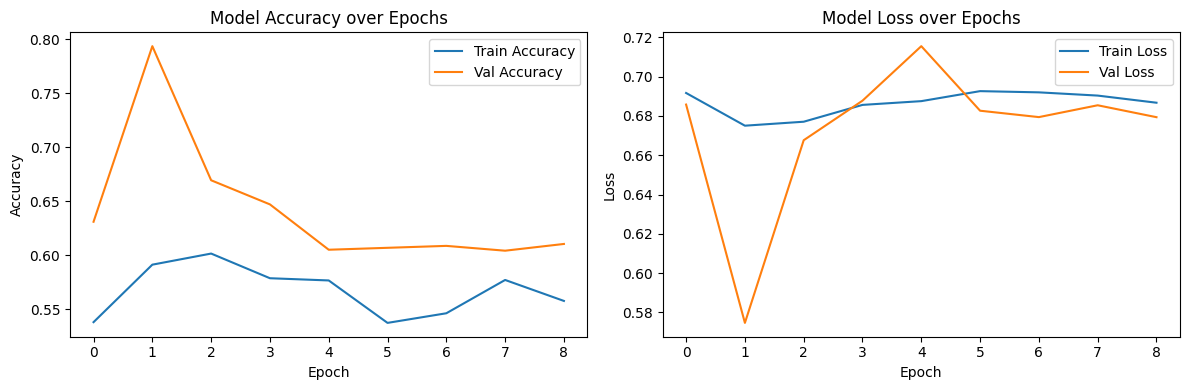

In [ ]:
#training history plottingD
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy over Epochs')
plt.legend()

# loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


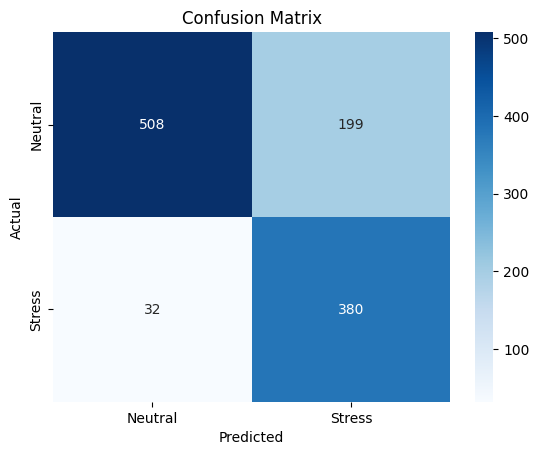

              precision    recall  f1-score   support

     Neutral       0.94      0.72      0.81       707
      Stress       0.66      0.92      0.77       412

    accuracy                           0.79      1119
   macro avg       0.80      0.82      0.79      1119
weighted avg       0.84      0.79      0.80      1119



In [ ]:
# confusion matrix + classification report
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = (lstm_model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neutral', 'Stress'],
            yticklabels=['Neutral', 'Stress'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Stress']))